In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')


In [11]:
conn=sqlite3.connect('inventory.db')
df=pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,209.32,1015032.27,21.062810,0.976890,1.266830
2,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144719.92,1015032.27,21.062810,0.976890,1.266830
3,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
4,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,12489.0,9672.998799,17519.491679,2.000000,3960.000000,4425.000000,9552.000000,2.013590e+05
Brand,12489.0,18847.561134,12524.982470,58.000000,6919.000000,19693.000000,25827.000000,9.063100e+04
PurchasePrice,12489.0,24.892217,103.582221,0.360000,7.140000,10.800000,20.430000,5.681810e+03
ActualPrice,12489.0,36.601191,141.237886,0.490000,10.990000,16.990000,29.990000,7.499990e+03
Volume,12489.0,838.294819,642.695329,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,12489.0,2946.748178,10618.653774,1.000000,36.000000,240.000000,1805.000000,3.376600e+05
TotalPurchaseDollars,12489.0,28401.808572,120334.186143,0.710000,472.860000,3545.640000,19227.600000,3.811252e+06
TotalSalesQuantity,12489.0,2886.526463,10481.304555,0.000000,32.000000,238.000000,1737.000000,3.349390e+05
TotalSalesDollars,12489.0,40048.985204,163562.626925,0.000000,782.130000,5124.790000,26505.120000,5.101920e+06
TotalSalesPrice,12489.0,17650.053082,42869.130243,0.000000,321.930000,2776.400000,14819.260000,6.728193e+05


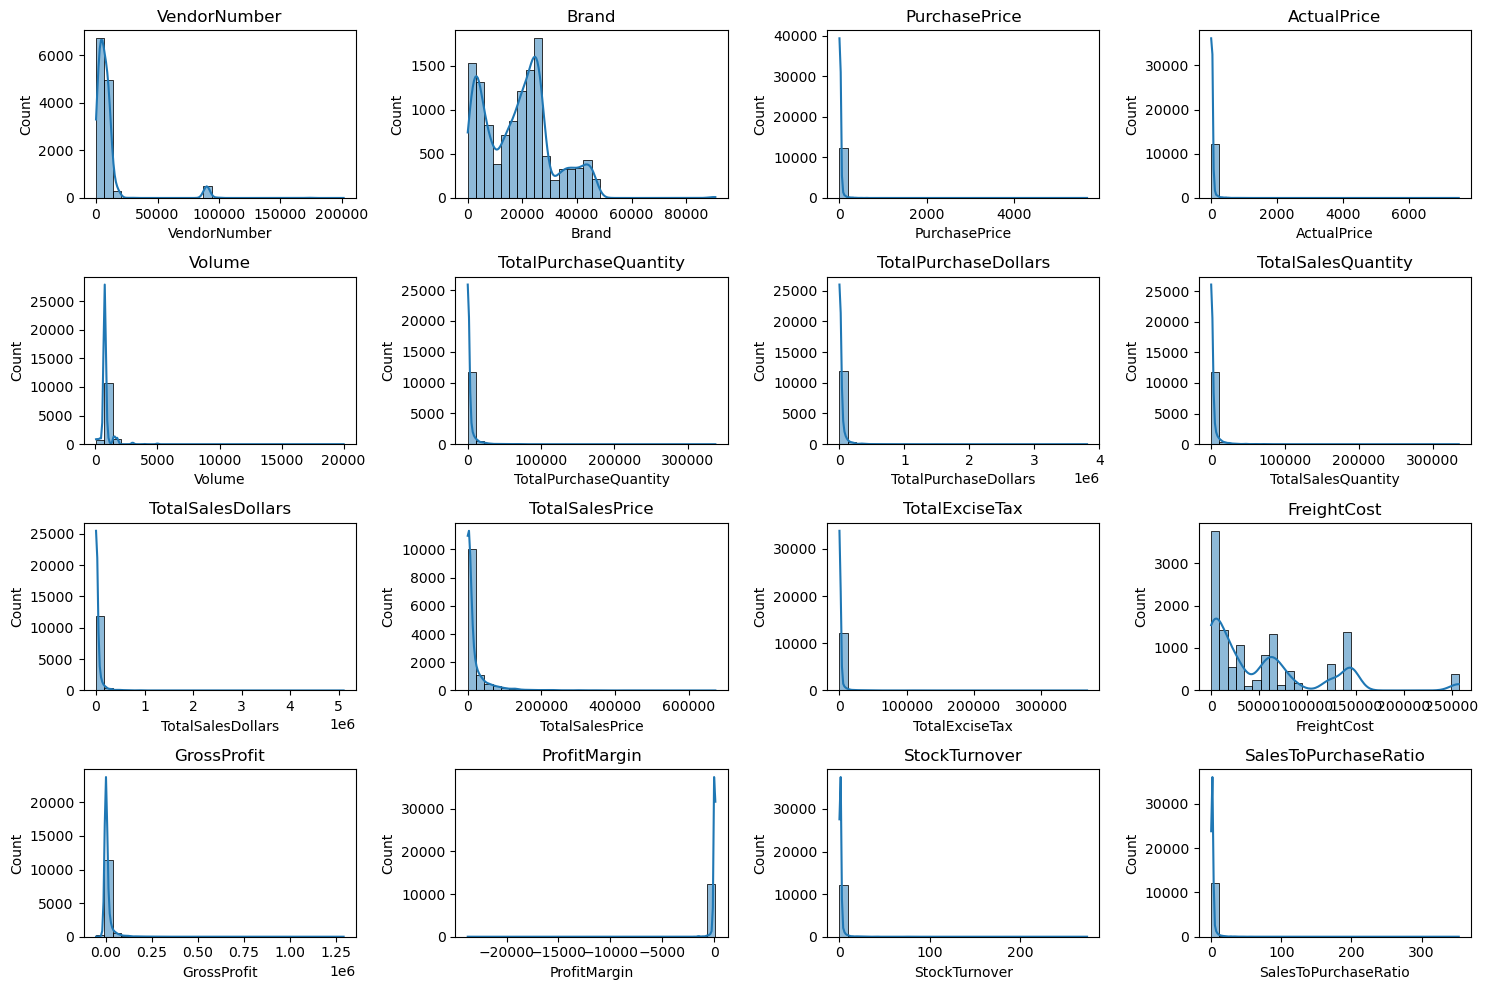

In [21]:
numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

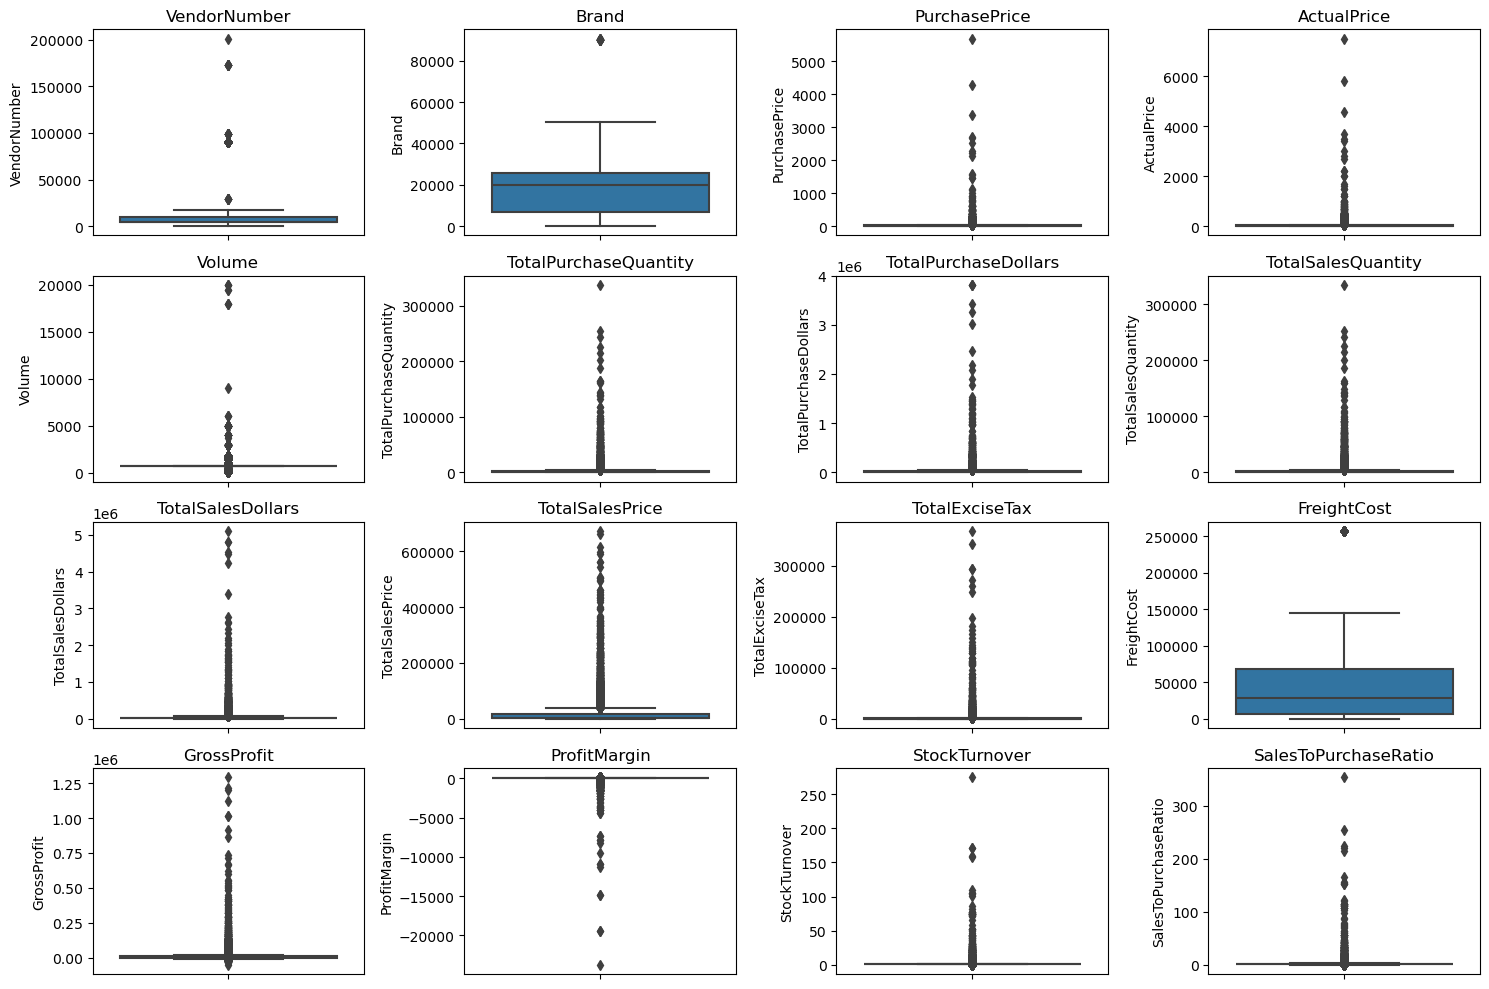

In [23]:
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [25]:
df=pd.read_sql_query("""select *
    from vendor_sales_summary
    where GrossProfit>0
    and profitMargin>0
    and TotalSalesQuantity>0""",conn)

In [27]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,209.32,1015032.27,21.062810,0.976890,1.266830
2,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144719.92,1015032.27,21.062810,0.976890,1.266830
3,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
4,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9970,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
9971,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
9972,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
9973,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


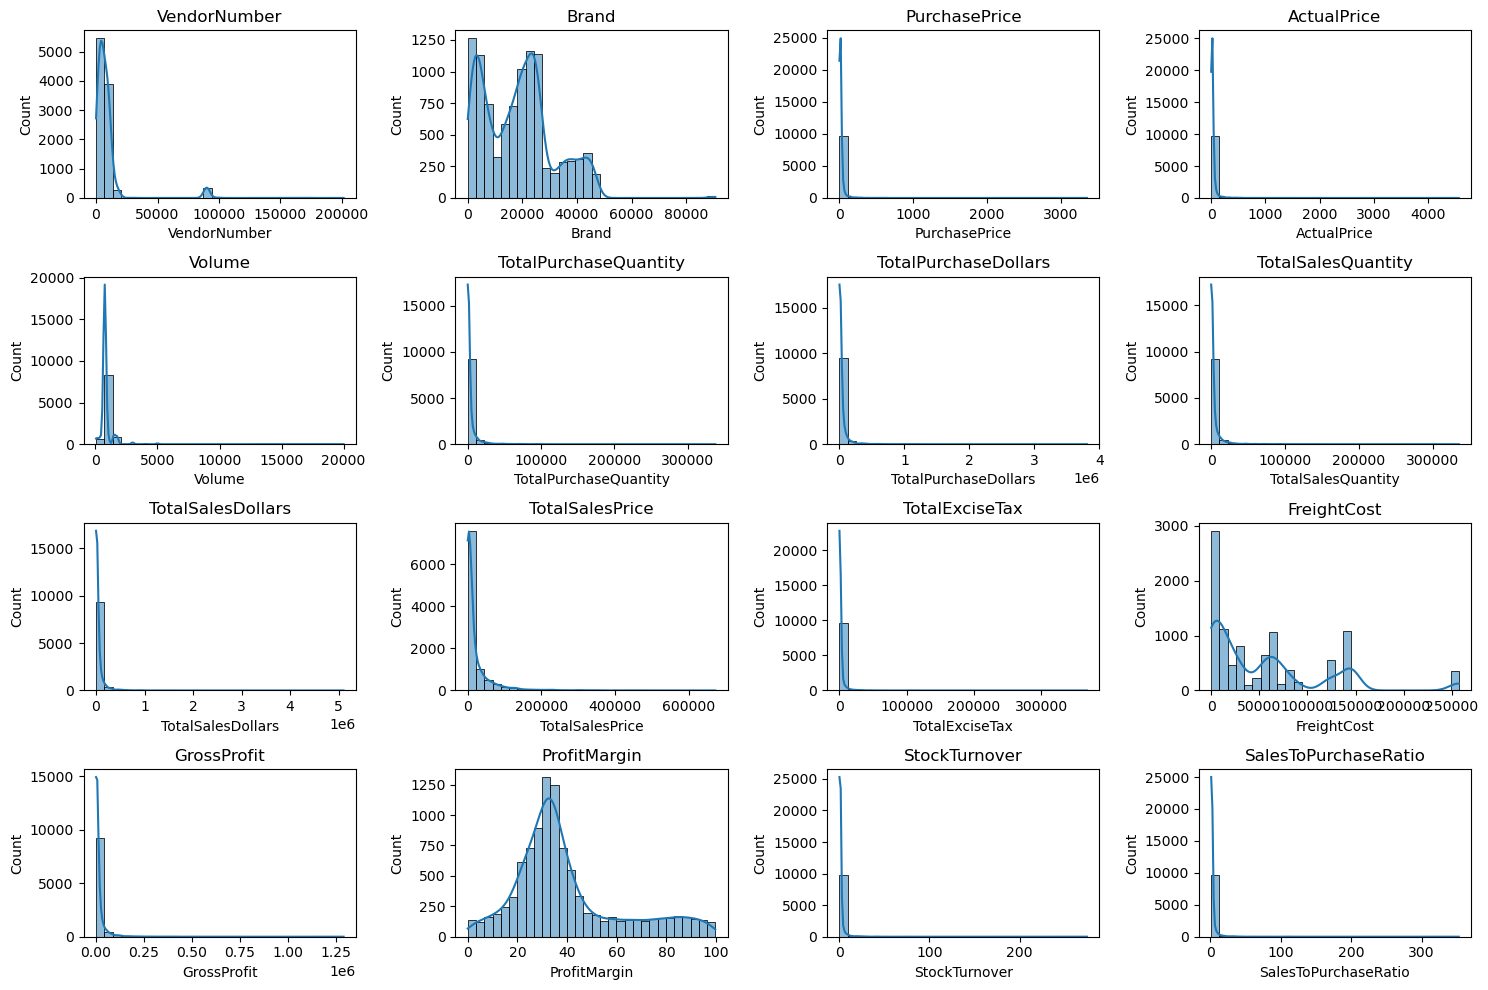

In [29]:
numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

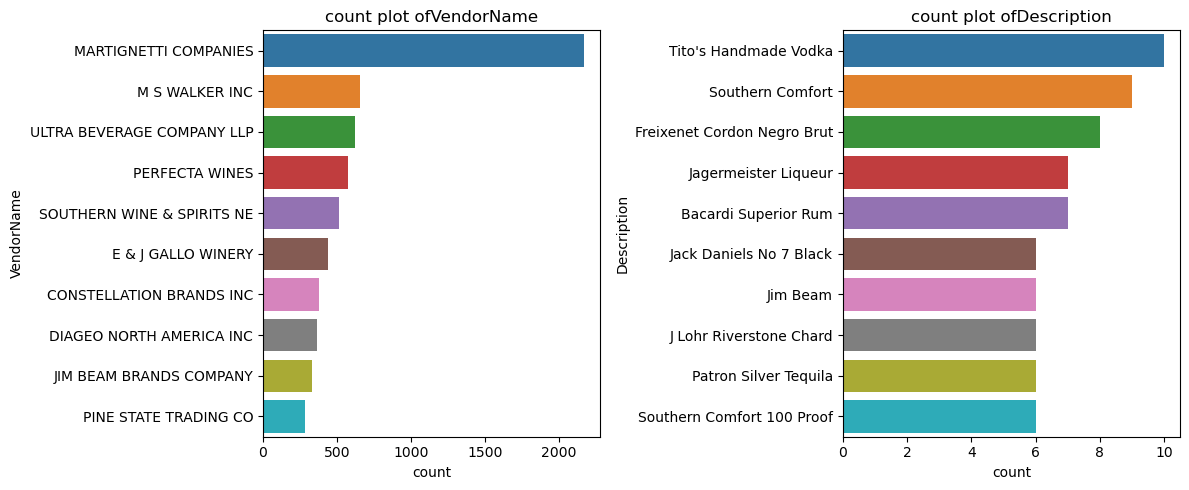

In [41]:
catagorical_cols=['VendorName','Description']
plt.figure(figsize=(12,5))
for i,col in enumerate(catagorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10])
    plt.title(f'count plot of{col}')
plt.tight_layout()
plt.show()

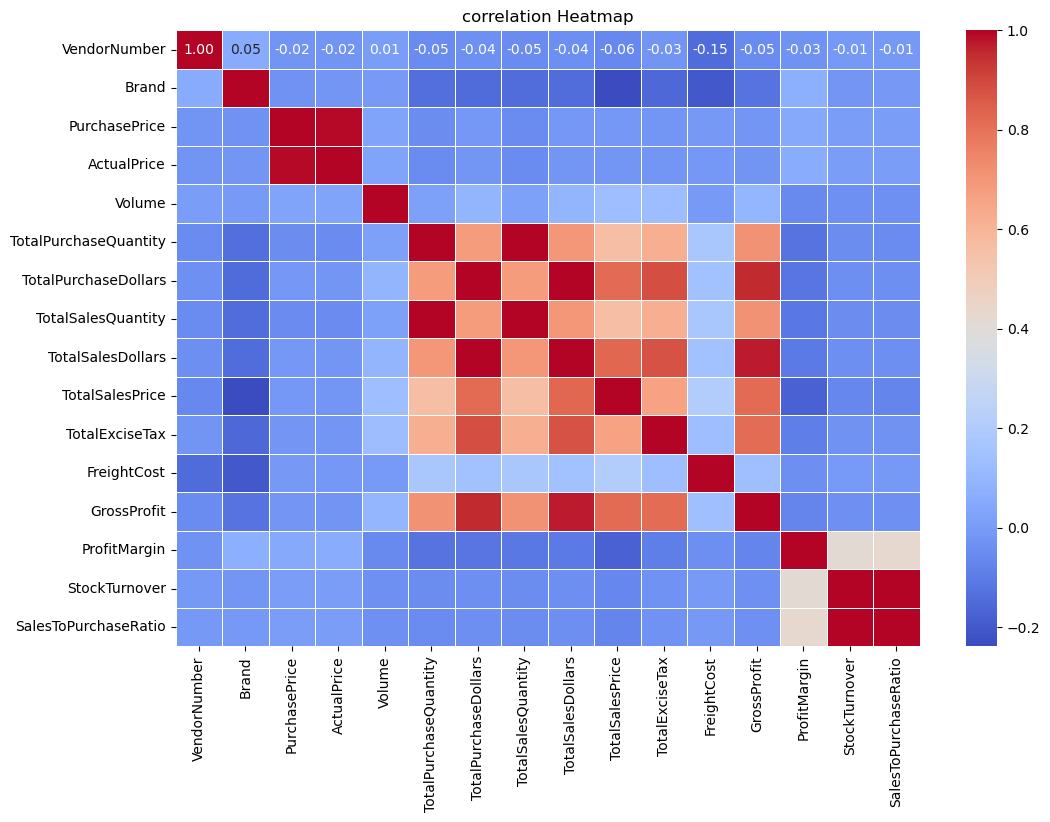

In [45]:
plt.figure(figsize=(12,8))
correlation_matrix=df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True, fmt='.2f' ,cmap='coolwarm', linewidths=0.5)
plt.title('correlation Heatmap')
plt.show()

In [65]:
brand_performence=df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [67]:
brand_performence

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [71]:
low_sales_threshold=brand_performence['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performence['ProfitMargin'].quantile(0.85)

In [74]:
low_sales_threshold

613.0259999999998

In [80]:
high_margin_threshold

65.04347864338612

In [94]:
target_brands=brand_performence[
    (brand_performence['TotalSalesDollars']<=low_sales_threshold)&
   ( brand_performence['ProfitMargin']>=high_margin_threshold)
]
print("Brands with low sales but high profit margins")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high profit margins


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
4817,Merriam Cab Franc Windacre V,594.83,80.523847
3479,Harthill Farms Cab Svgn,595.03,89.956809
5530,Philippe Herard Bl de Blanc,607.24,71.174494
4616,Malibu Cosmo Light RTD,610.59,66.537284


In [110]:
brand_performence=brand_performence[brand_performence['TotalSalesDollars']<10000]

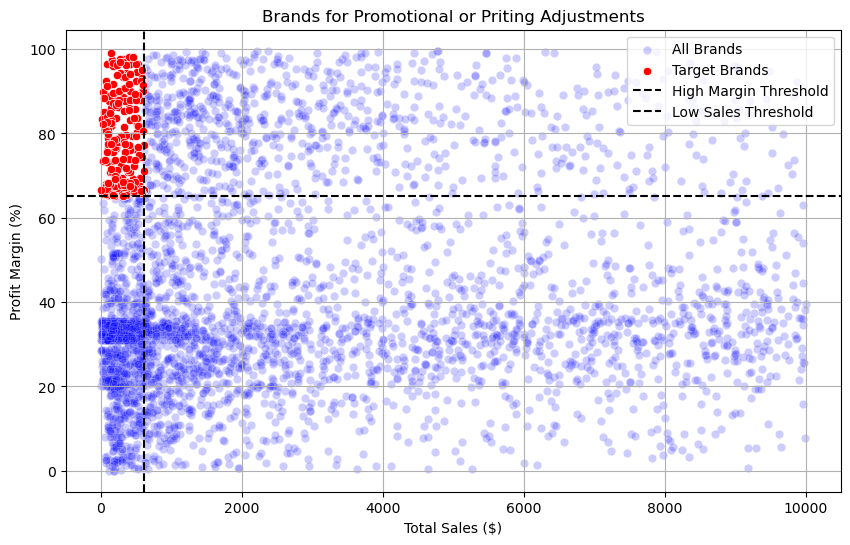

In [112]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performence, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x= 'TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")
plt.axhline(high_margin_threshold, linestyle='--', color='black', label= "High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Priting Adjustments")

plt.legend()
plt.grid(True)
plt.show()

In [205]:
def format_dollars(value):
    if value>=1_000_000:
        return f'{value/1_000_000:.2f}M'
    elif value>=1_000:
        return f'{value/1_000:.2f}k'
    else:
        return str(value)
    

In [207]:
top_vendors=df.groupby("VendorName")['TotalSalesDollars'].sum().nlargest(10)
top_brands=df.groupby("Description")['TotalSalesDollars'].sum().nlargest(10)
top_vendors

VendorName
MARTIGNETTI COMPANIES         7.866072e+07
DIAGEO NORTH AMERICA INC      6.799010e+07
PERNOD RICARD USA             3.206320e+07
JIM BEAM BRANDS COMPANY       3.142302e+07
BACARDI USA INC               2.485482e+07
CONSTELLATION BRANDS INC      2.421875e+07
E & J GALLO WINERY            1.839990e+07
BROWN-FORMAN CORP             1.824723e+07
ULTRA BEVERAGE COMPANY LLP    1.650254e+07
M S WALKER INC                1.470646e+07
Name: TotalSalesDollars, dtype: float64

In [209]:
top_brands

Description
Tito's Handmade Vodka      14799315.16
Jack Daniels No 7 Black     7964746.76
Grey Goose Vodka            7209608.06
Capt Morgan Spiced Rum      6356320.62
Absolut 80 Proof            6244752.03
Jameson Irish Whiskey       5715759.69
Ketel One Vodka             5070083.56
Baileys Irish Cream         4150122.07
Kahlua                      3604858.66
Tanqueray                   3456697.90
Name: TotalSalesDollars, dtype: float64

In [211]:
top_brands.apply(lambda x :format_dollars(x))

Description
Tito's Handmade Vodka      14.80M
Jack Daniels No 7 Black     7.96M
Grey Goose Vodka            7.21M
Capt Morgan Spiced Rum      6.36M
Absolut 80 Proof            6.24M
Jameson Irish Whiskey       5.72M
Ketel One Vodka             5.07M
Baileys Irish Cream         4.15M
Kahlua                      3.60M
Tanqueray                   3.46M
Name: TotalSalesDollars, dtype: object

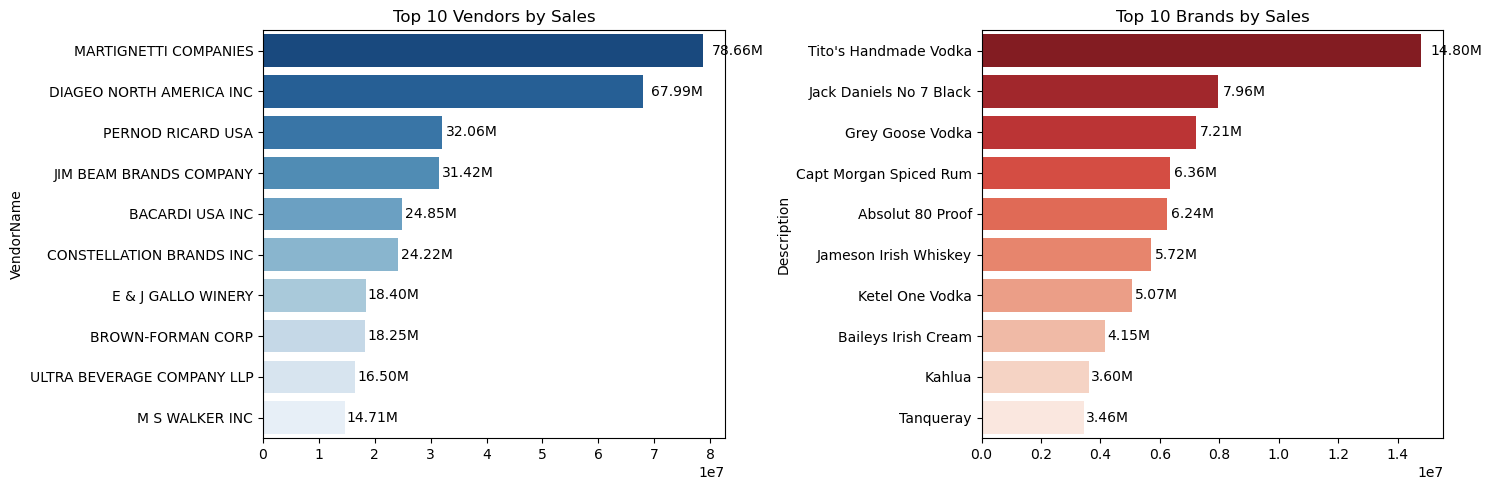

In [213]:

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
ax1 =sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2, 
             format_dollars(bar.get_width()), 
             ha='left', va='center', fontsize=10, color='black')

plt.subplot(1, 2, 2)
ax2= sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02), 
         bar.get_y() + bar.get_height() / 2,
         format_dollars(bar.get_width()),
         ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

## which vendor contribute the most to the total purchase dollar?

In [228]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape

(119, 4)

In [324]:
vendor_performance['PurchaseContribution%']=(vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum())*100


In [326]:
vendor_performance= round (vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [328]:
top_vendors=vendor_performance.head(10)
top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)
top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
57,MARTIGNETTI COMPANIES,51.00M,27.66M,78.66M,15.11
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,14.84
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.07
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,6.96
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.17
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.53
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,3.92
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.58
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.31
53,M S WALKER INC,9.76M,4.94M,14.71M,2.89


In [330]:
top_vendors['PurchaseContribution%'].sum()

67.38000000000001

In [332]:
top_vendors['Cumulative_Contribution%']= top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
57,MARTIGNETTI COMPANIES,51.00M,27.66M,78.66M,15.11,15.11
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,14.84,29.95
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.07,37.02
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,6.96,43.98
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.17,49.15
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.53,53.68
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,3.92,57.60
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.58,61.18
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.31,64.49
53,M S WALKER INC,9.76M,4.94M,14.71M,2.89,67.38


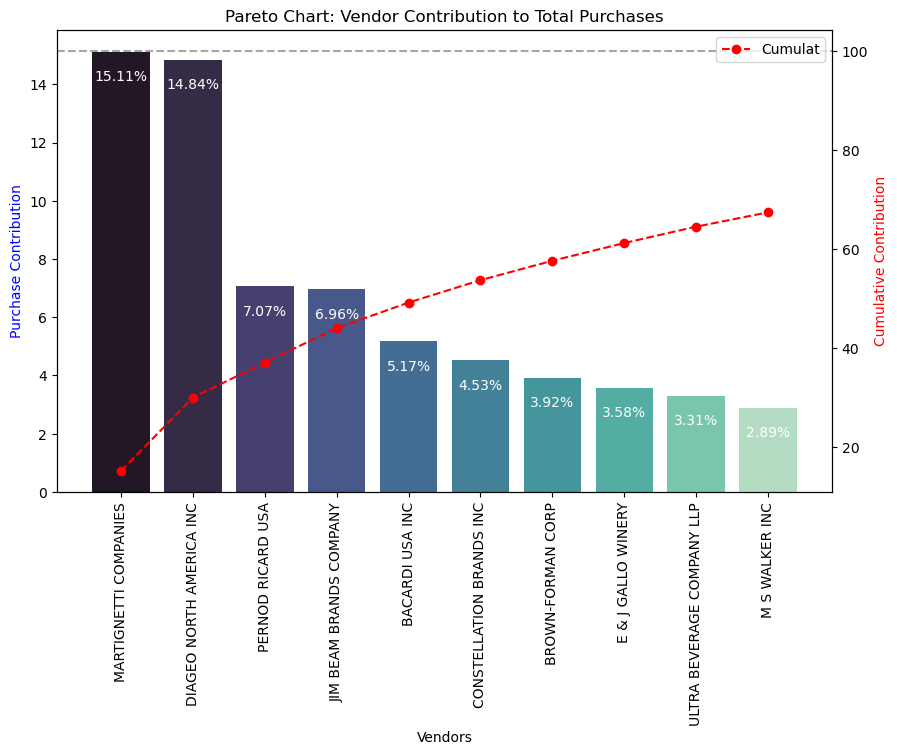

In [334]:
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution%'],
    palette="mako",
    ax=ax1
)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value) + '%', ha='center', fontsize=10, color='white')

ax2 = ax1.twinx()
ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulat'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)

ax1.set_ylabel('Purchase Contribution', color='blue')
ax2.set_ylabel('Cumulative Contribution', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

## how much of total precurement is depend on  top vendors?

In [337]:
print(f"total purchase contribution of top 10 vendor is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

total purchase contribution of top 10 vendor is 67.38 %


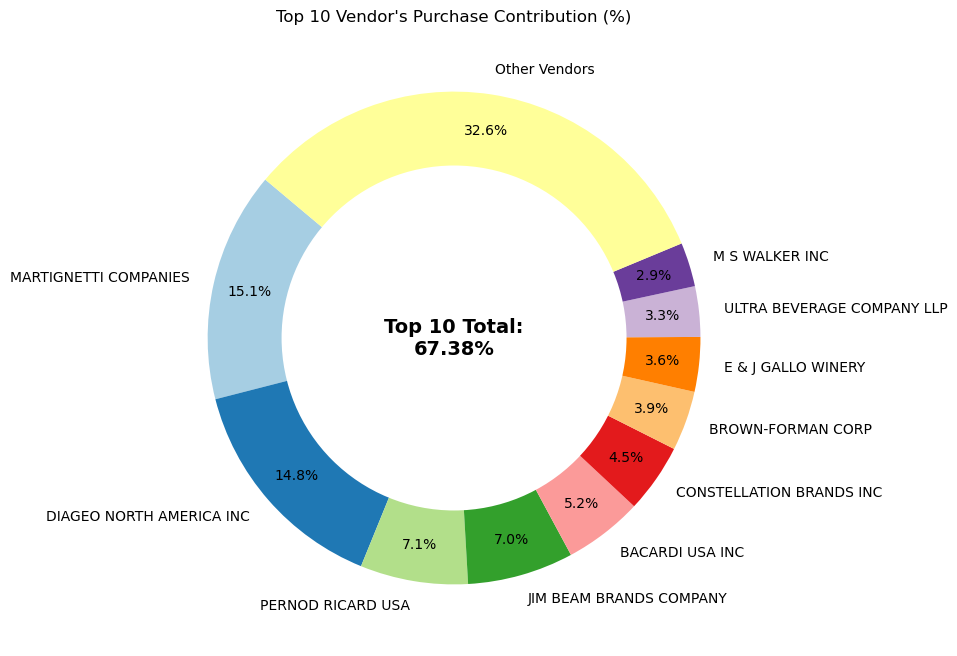

In [339]:
vendors = list(top_vendors['VendorName'].values)

purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")

plt.show()

### does purchasing in bulk reduce the unit price,what is the optimal purchase volume for cost saving?

In [341]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/ df ['TotalPurchaseQuantity']

In [343]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,209.32,1015032.27,21.062810,0.976890,1.266830,23.19
2,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144719.92,1015032.27,21.062810,0.976890,1.266830,23.19
3,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
4,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9970,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
9971,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
9972,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74
9973,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47


In [352]:
df['OrderSize']=pd.qcut(df['TotalPurchaseQuantity'],q=3, labels=['small','medium',',large'])

In [358]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,",large",145080
1,",large",164038
2,",large",164038
3,",large",187407
4,",large",201682
...,...,...
9970,small,2
9971,small,6
9972,small,2
9973,small,1


In [360]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
small,40.746692
medium,15.588058
",large",10.873970


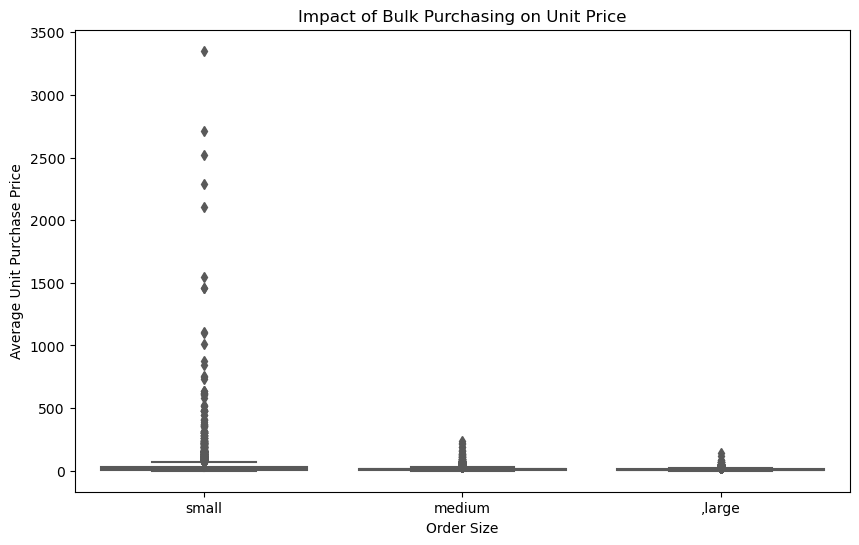

In [364]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")

plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")

plt.show()

## which vendor have low inventry turnover , indicating excess stock and slow moving products?


In [379]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


## how much capital is locked in unsold inventry  per vendor,and which vendor contribute most to it?


In [388]:
df['UnsoldInventoryValue']=(df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])*df['PurchasePrice']
print('Total unsold capital:', format_dollars(df['UnsoldInventoryValue'].sum()))

Total unsold capital: 2.55M


In [392]:
inventory_value_per_vendor = df.groupby ("VendorName") ["UnsoldInventoryValue"].sum().reset_index()

inventory_value_per_vendor = inventory_value_per_vendor.sort_values (by="UnsoldInventoryValue", ascending =False)
inventory_value_per_vendor ['UnsoldInventoryValue']= inventory_value_per_vendor ['UnsoldInventoryValue'].apply(format_dollars)

inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21k
46,JIM BEAM BRANDS COMPANY,554.67k
68,PERNOD RICARD USA,470.63k
116,WILLIAM GRANT & SONS INC,401.96k
30,E & J GALLO WINERY,228.28k
79,SAZERAC CO INC,198.44k
11,BROWN-FORMAN CORP,177.73k
20,CONSTELLATION BRANDS INC,133.62k
61,MOET HENNESSY USA INC,126.48k
77,REMY COINTREAU USA INC,118.60k


## what is 95% confidence intervals for profit margin of top performing and low performing vendors

In [395]:
top_threshold=df['TotalSalesDollars'].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

In [397]:
top_vendors=df[df['TotalPurchaseDollars']>= top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalPurchaseDollars']<= low_threshold]['ProfitMargin'].dropna()

In [399]:
top_vendors

0       25.297693
1       21.062810
2       21.062810
3       24.675786
4       27.139908
          ...    
1838    23.091573
1839    32.788915
1840    32.788915
1841    26.832199
1842    59.969863
Name: ProfitMargin, Length: 1843, dtype: float64

In [401]:
low_vendors

6414    34.987914
6415    30.417981
6416    30.417981
6417    29.618372
6418    81.551761
          ...    
9970    83.448276
9971    96.436186
9972    25.252525
9973    98.974037
9974    99.166079
Name: ProfitMargin, Length: 3561, dtype: float64

In [407]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))

    # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (29.24, 30.06), Mean: 29.65
Low Vendors 95% CI: (49.68, 51.52), Mean: 50.60


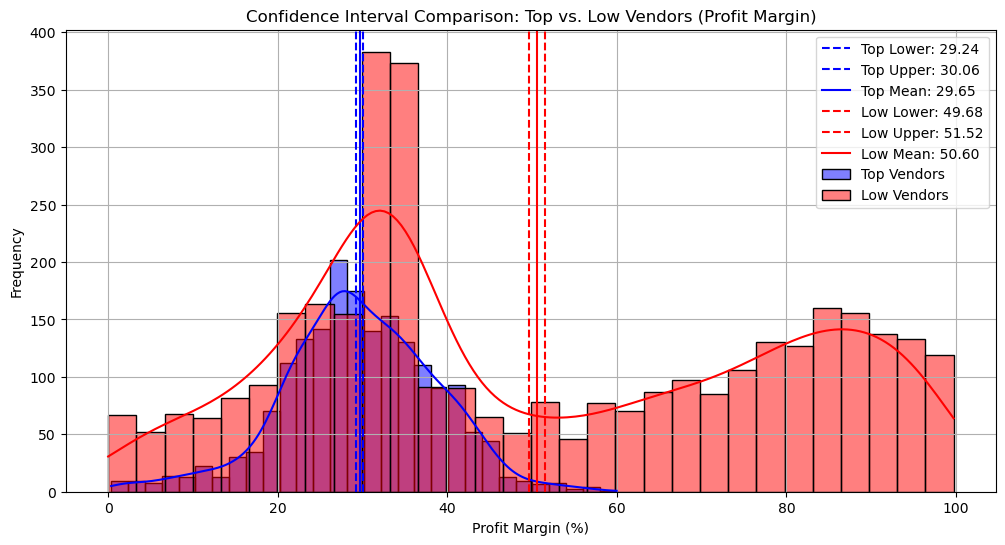

In [411]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)

low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")

plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")

plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

## Is therer a significant difference in profit margin betweeen  top_performing and  low Performing vendors?

In [416]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)

low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()

low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject Ha: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject He: No significant difference in profit margins.")

T-Statistic: -19.4271, P-Value: 0.0000
Reject Ha: There is a significant difference in profit margins between top and low-performing vendors.


In [ ]:
import shutil

shutil.make_archive(
    "C:/Users/Noman/Vendor_Analytics_Project",
    "zip",
    "C:/Users/Noman/vendor ana pro"
)